# ============================================================
# TASK 1: Term Deposit Subscription Prediction (Bank Marketing)
# DevelopersHub Corporation – Data Science Internship
# ============================================================

In [1]:
!pip install shap --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_curve, auc, ConfusionMatrixDisplay)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
!unzip -q bank-additional.zip

# Load the full dataset (semicolon separated)
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')
print("Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded!
Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.

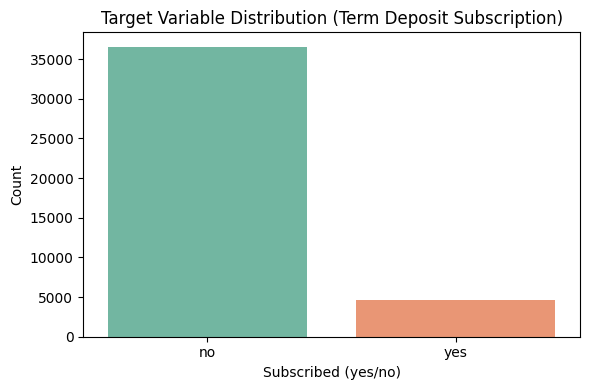

In [4]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Variable Distribution ===")
print(df['y'].value_counts())

# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Target Variable Distribution (Term Deposit Subscription)')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
df_encoded = df.copy()

# Replace 'unknown' with NaN and fill with mode
df_encoded.replace('unknown', np.nan, inplace=True)
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col].fillna(df_encoded[col].mode()[0], inplace=True)

# Encode target variable
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# Label encode all categorical columns
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoding complete!")
df_encoded.head()

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Encoding complete!


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


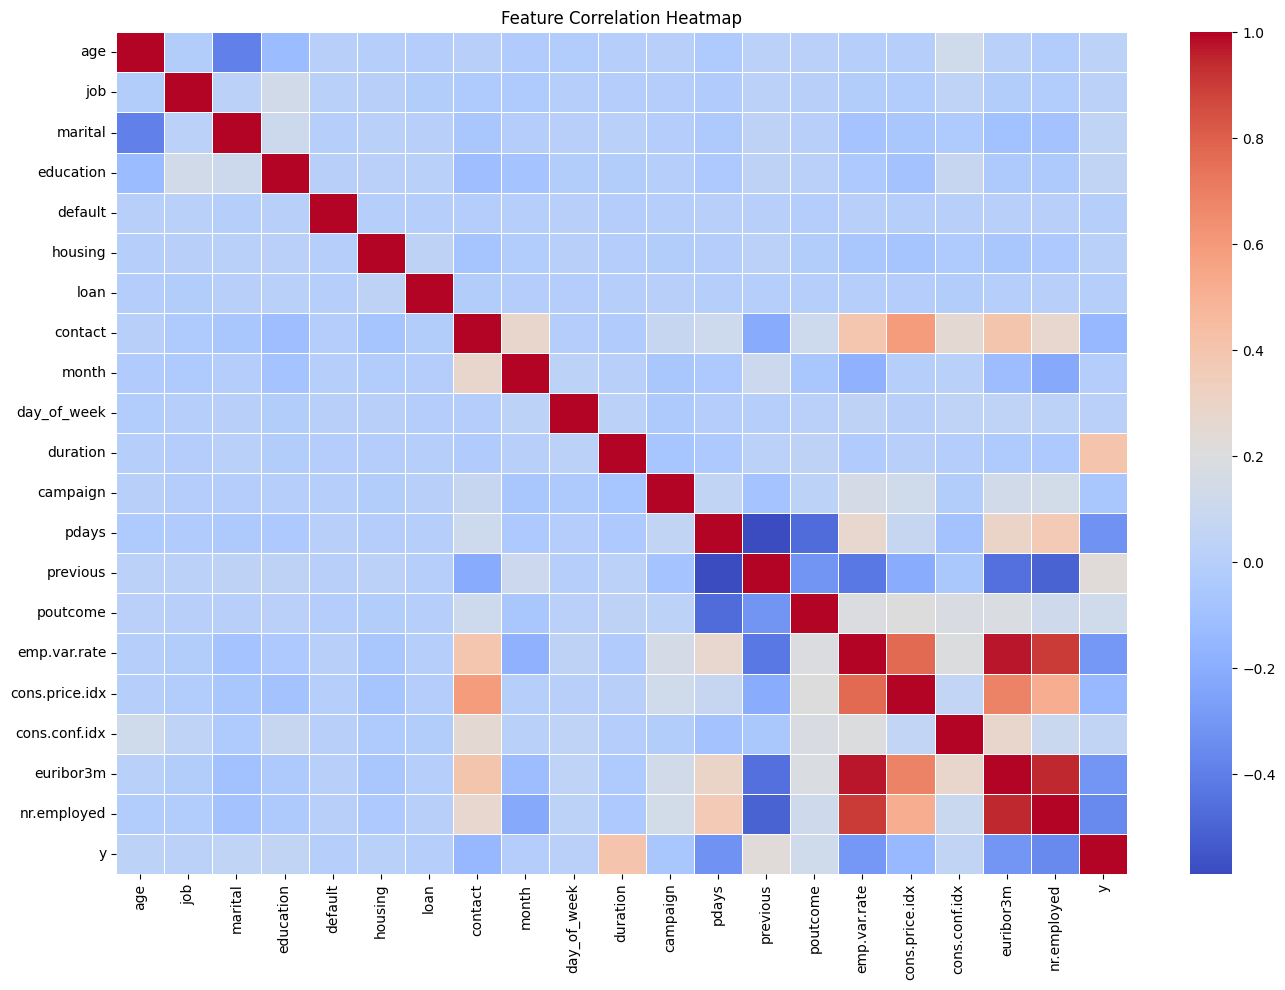

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (32950, 20), Test size: (8238, 20)


=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.69      0.74      8238
weighted avg       0.90      0.91      0.90      8238

F1 Score: 0.5187


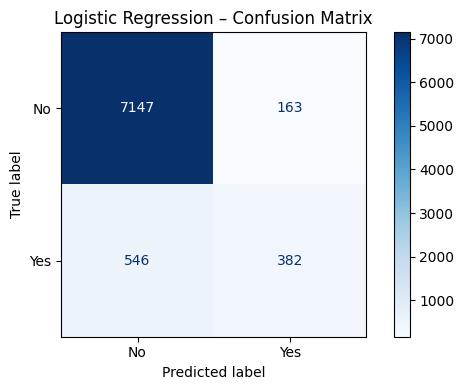

In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_preds))
print(f"F1 Score: {f1_score(y_test, lr_preds):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, ax=ax,
                                         display_labels=['No', 'Yes'],
                                         cmap='Blues')
ax.set_title('Logistic Regression – Confusion Matrix')
plt.tight_layout()
plt.show()

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7310
           1       0.69      0.53      0.60       928

    accuracy                           0.92      8238
   macro avg       0.82      0.75      0.78      8238
weighted avg       0.91      0.92      0.92      8238

F1 Score: 0.5991


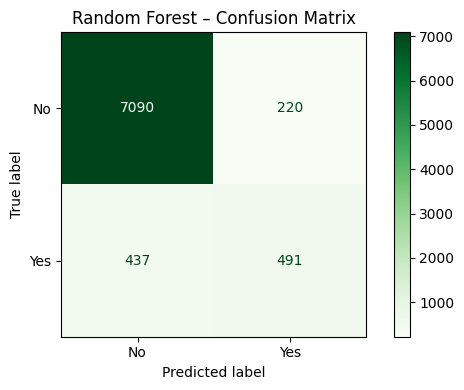

In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_preds))
print(f"F1 Score: {f1_score(y_test, rf_preds):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax,
                                         display_labels=['No', 'Yes'],
                                         cmap='Greens')
ax.set_title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()

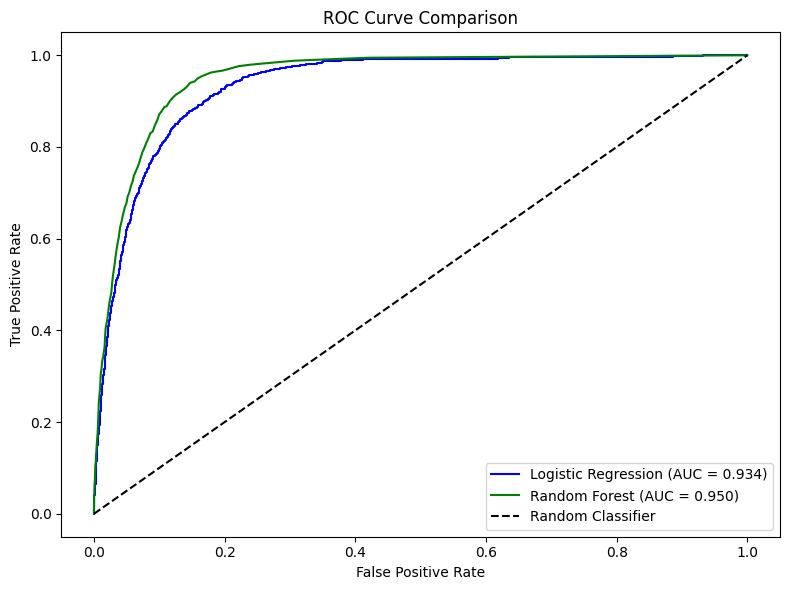

In [10]:
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
lr_probs = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='blue')

# Random Forest ROC
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

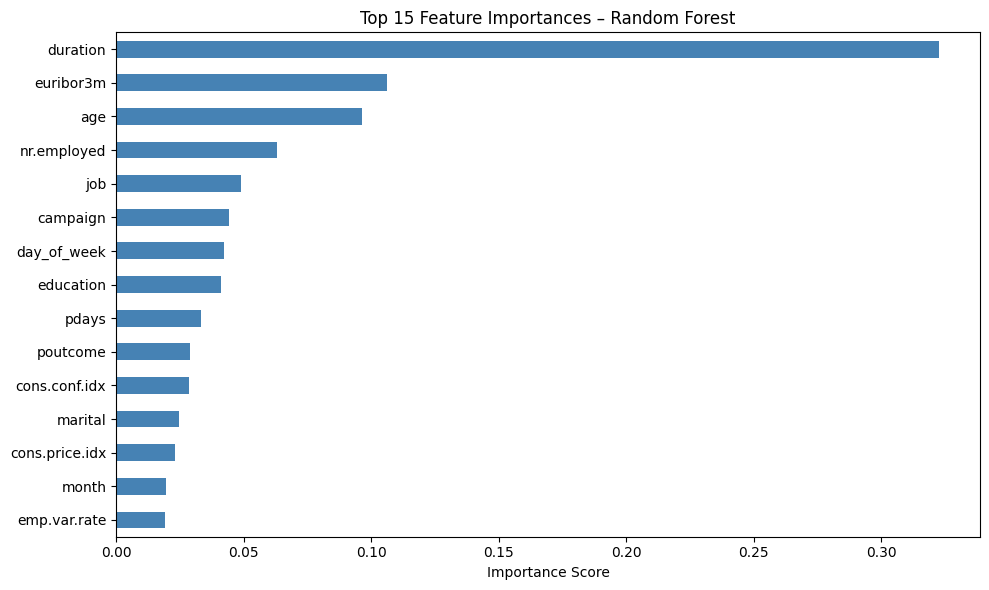

In [11]:
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feat_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Computing SHAP values (this may take ~1-2 min)...
SHAP values shape: (200, 20)
X_sample shape   : (200, 20)


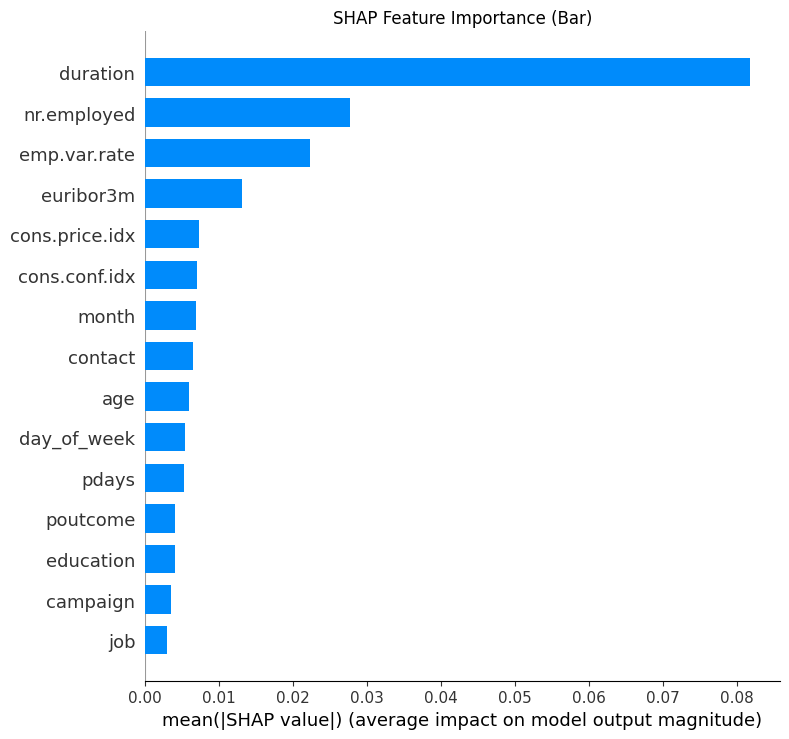

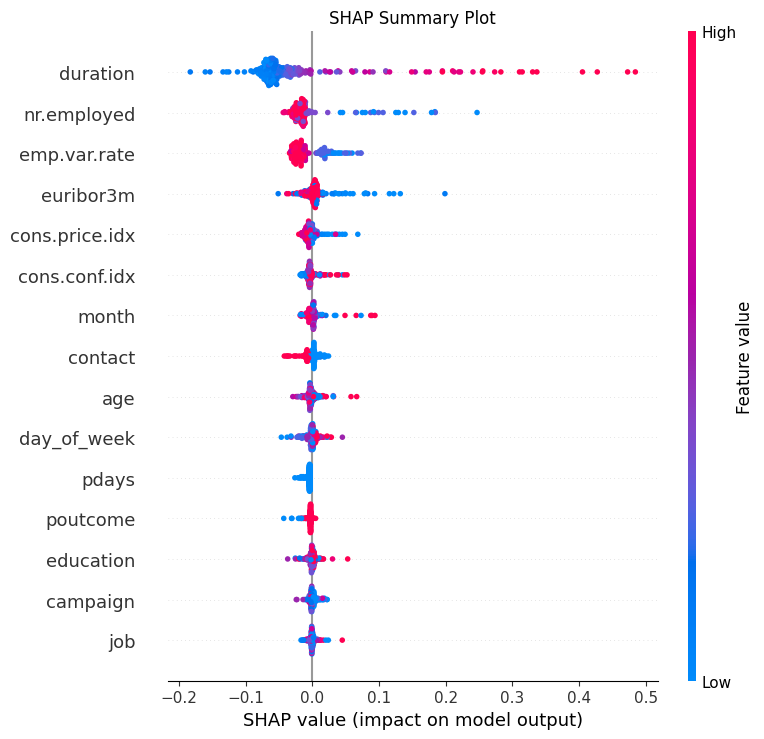

In [14]:
print("Computing SHAP values (this may take ~1-2 min)...")

X_sample = X_test.sample(200, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_sample)

# Handle both old and new SHAP versions
# Old: shap_values is a list [class0_array, class1_array]
# New: shap_values is a 3D array of shape (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    shap_vals_class1 = shap_values_raw[1]  # old SHAP
else:
    shap_vals_class1 = shap_values_raw[:, :, 1]  # new SHAP

print(f"SHAP values shape: {shap_vals_class1.shape}")
print(f"X_sample shape   : {X_sample.shape}")

# SHAP Summary Bar Plot
shap.summary_plot(shap_vals_class1, X_sample, plot_type='bar',
                  show=False, max_display=15)
plt.title('SHAP Feature Importance (Bar)')
plt.tight_layout()
plt.show()

# SHAP Beeswarm Summary Plot
shap.summary_plot(shap_vals_class1, X_sample, show=False, max_display=15)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

=== SHAP Explanation for 5 Individual Predictions ===

--- Prediction 1 ---
Actual   : Not Subscribed
Predicted: Not Subscribed


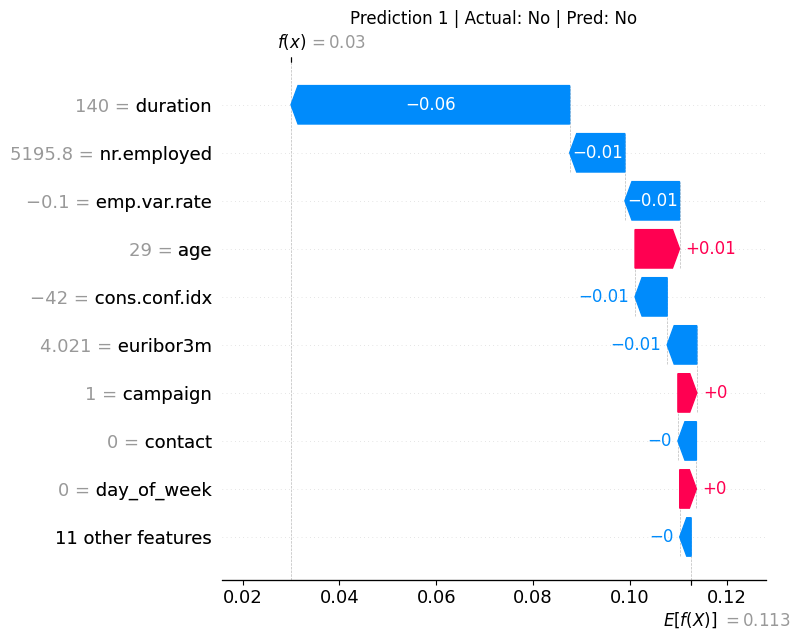


--- Prediction 2 ---
Actual   : Not Subscribed
Predicted: Not Subscribed


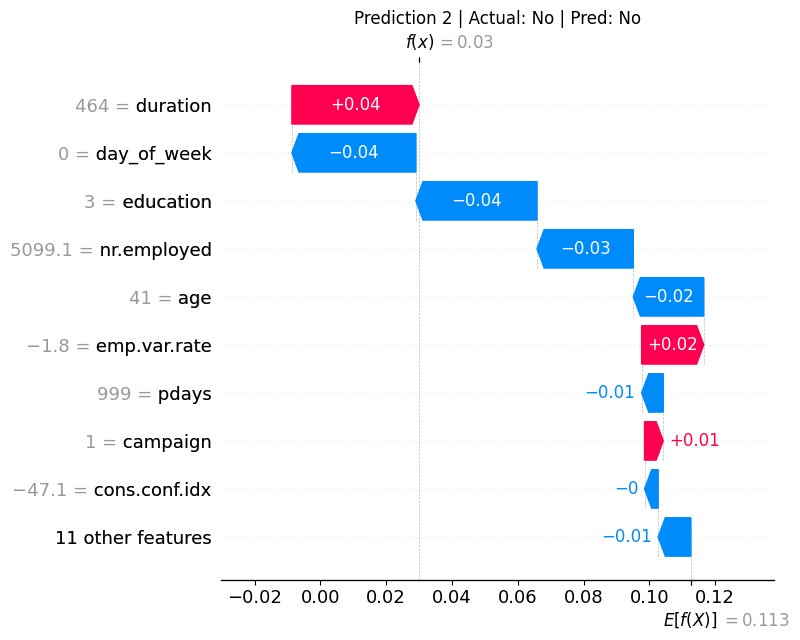


--- Prediction 3 ---
Actual   : Not Subscribed
Predicted: Not Subscribed


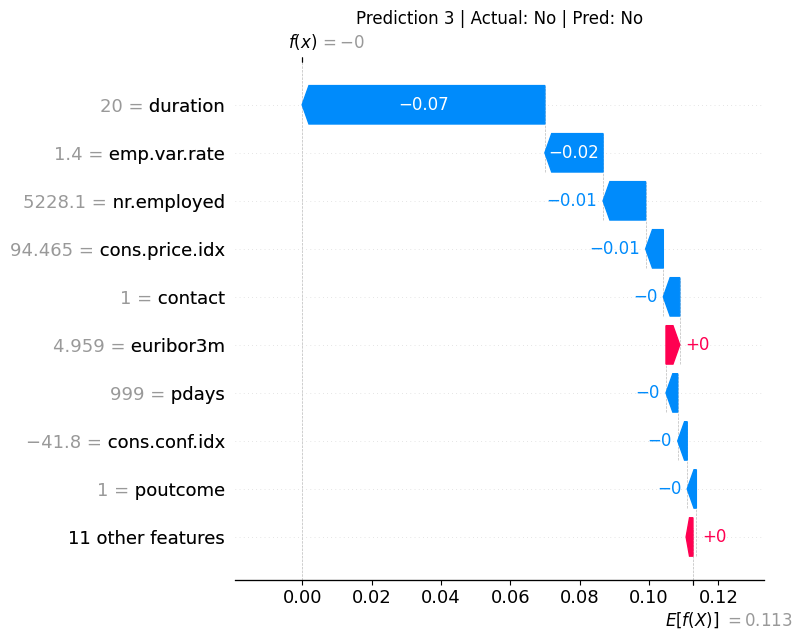


--- Prediction 4 ---
Actual   : Not Subscribed
Predicted: Not Subscribed


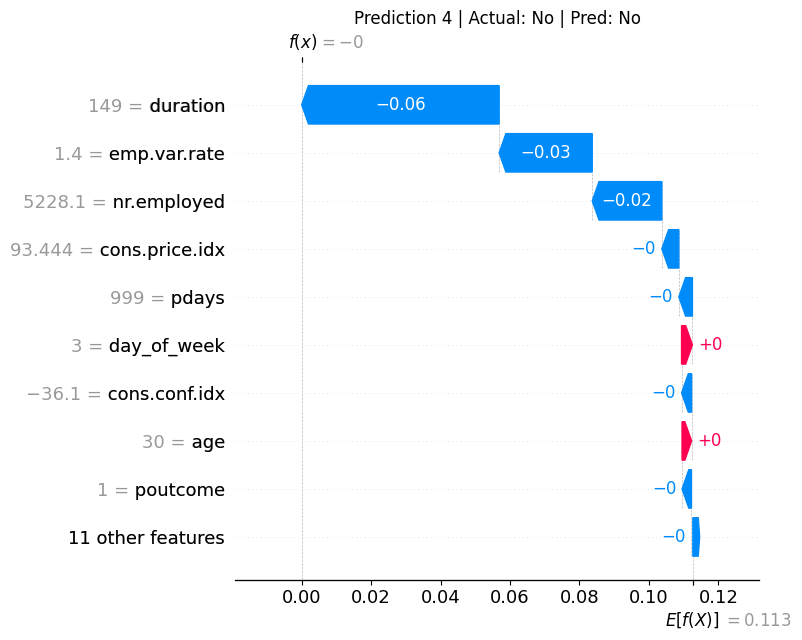


--- Prediction 5 ---
Actual   : Not Subscribed
Predicted: Not Subscribed


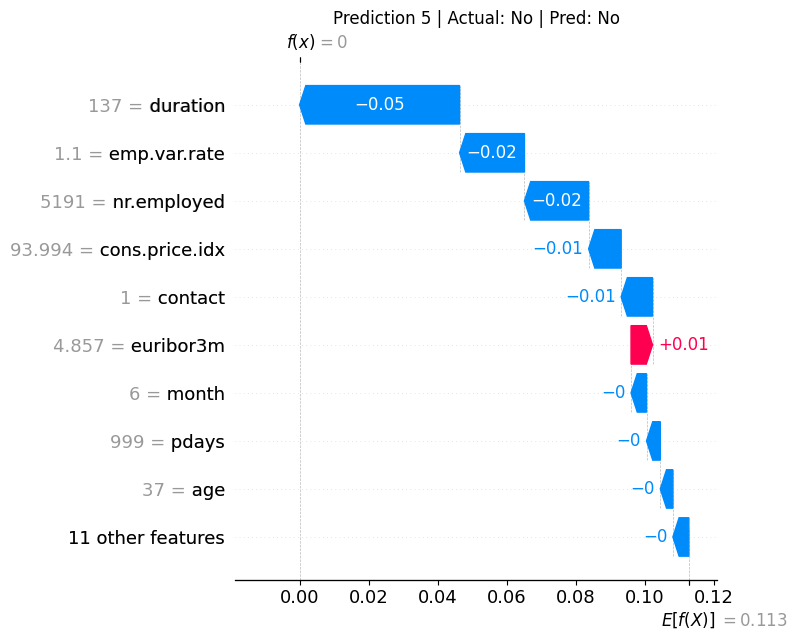

In [17]:

print("=== SHAP Explanation for 5 Individual Predictions ===")

# Get base value for class 1
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

for i in range(5):
    predicted = rf_model.predict(X_sample.iloc[[i]])[0]
    actual_val = y_test.reset_index(drop=True).iloc[i]

    print(f"\n--- Prediction {i+1} ---")
    print(f"Actual   : {'Subscribed' if actual_val==1 else 'Not Subscribed'}")
    print(f"Predicted: {'Subscribed' if predicted==1 else 'Not Subscribed'}")

    # Build SHAP Explanation object for waterfall plot
    exp = shap.Explanation(
        values      = shap_vals_class1[i],
        base_values = base_value,
        data        = X_sample.iloc[i].values,
        feature_names = X_sample.columns.tolist()
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f'Prediction {i+1} | Actual: {"Yes" if actual_val==1 else "No"} | '
              f'Pred: {"Yes" if predicted==1 else "No"}')
    plt.tight_layout()
    plt.show()

In [18]:
print("=" * 55)
print("           TASK 1 – FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset Shape         : {df.shape}")
print(f"  Features Used         : {X.shape[1]}")
print(f"  Train/Test Split      : 80% / 20%")
print()
print(f"  Logistic Regression:")
print(f"    F1 Score            : {f1_score(y_test, lr_preds):.4f}")
print(f"    AUC                 : {auc_lr:.4f}")
print()
print(f"  Random Forest:")
print(f"    F1 Score            : {f1_score(y_test, rf_preds):.4f}")
print(f"    AUC                 : {auc_rf:.4f}")
print()
print(" SHAP explanations generated for 5 predictions")
print("=" * 55)

           TASK 1 – FINAL SUMMARY
  Dataset Shape         : (41188, 21)
  Features Used         : 20
  Train/Test Split      : 80% / 20%

  Logistic Regression:
    F1 Score            : 0.5187
    AUC                 : 0.9344

  Random Forest:
    F1 Score            : 0.5991
    AUC                 : 0.9503

 SHAP explanations generated for 5 predictions
